In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle

import subcluster_funcs as funcs
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)
plots_dir = "plots_dir/"
os.makedirs(plots_dir, exist_ok=True)

In [3]:
cell_type = "Lymphoid"

In [4]:
%%time
adata = sc.read_h5ad("../continuous_cov_corrected_no_scvi/" + cell_type  + ".h5ad")

CPU times: user 25.9 s, sys: 4.59 s, total: 30.5 s
Wall time: 38.5 s


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>

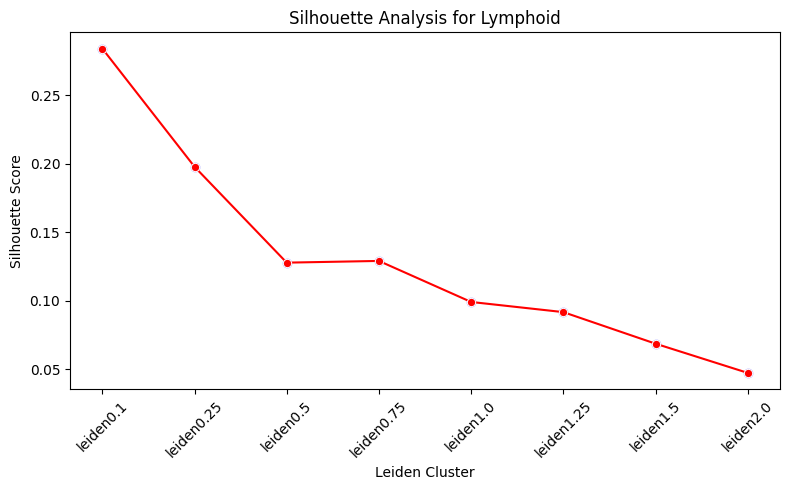

In [5]:
funcs.silhouette(adata, silhouette_res_dir = "../silhouette_res_scVI/", cell_type = cell_type)

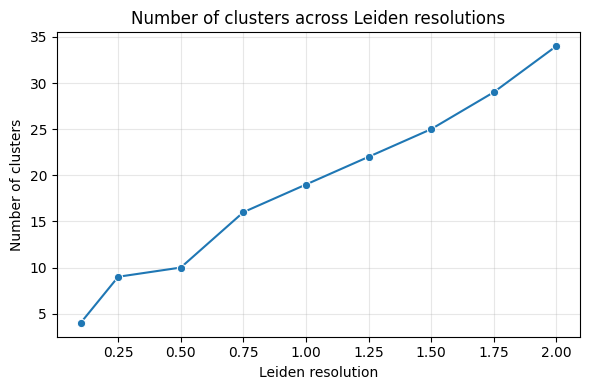

In [6]:
cluster_df, fig = funcs.leiden_resolution_summary(adata)

### Use leiden 0.25

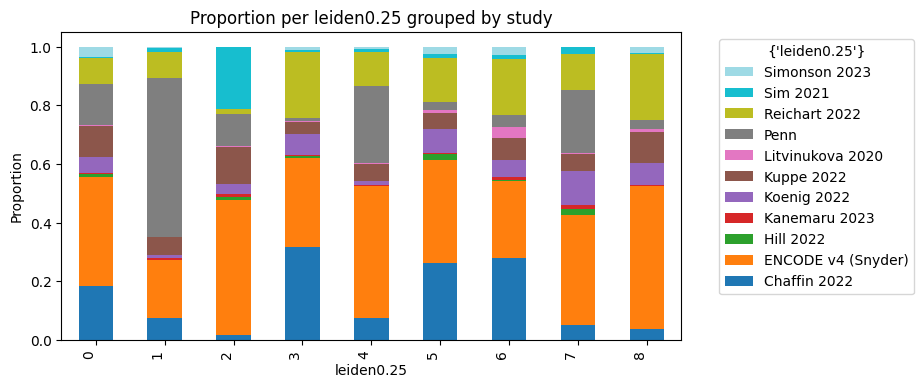

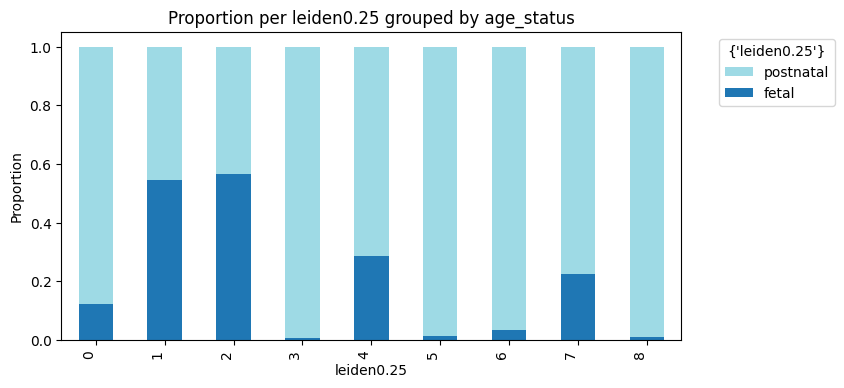

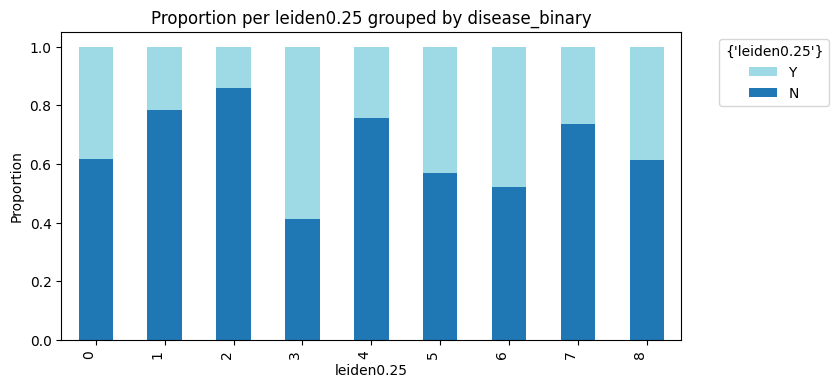

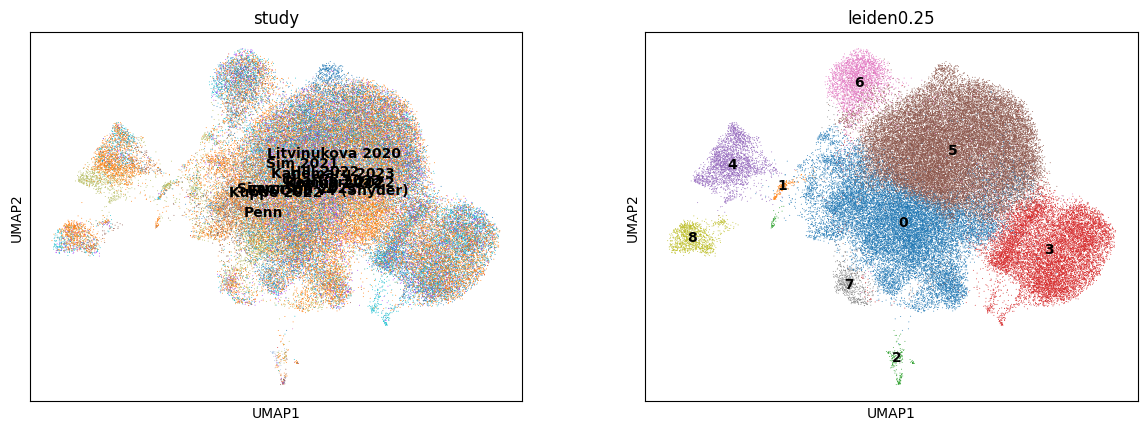

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean

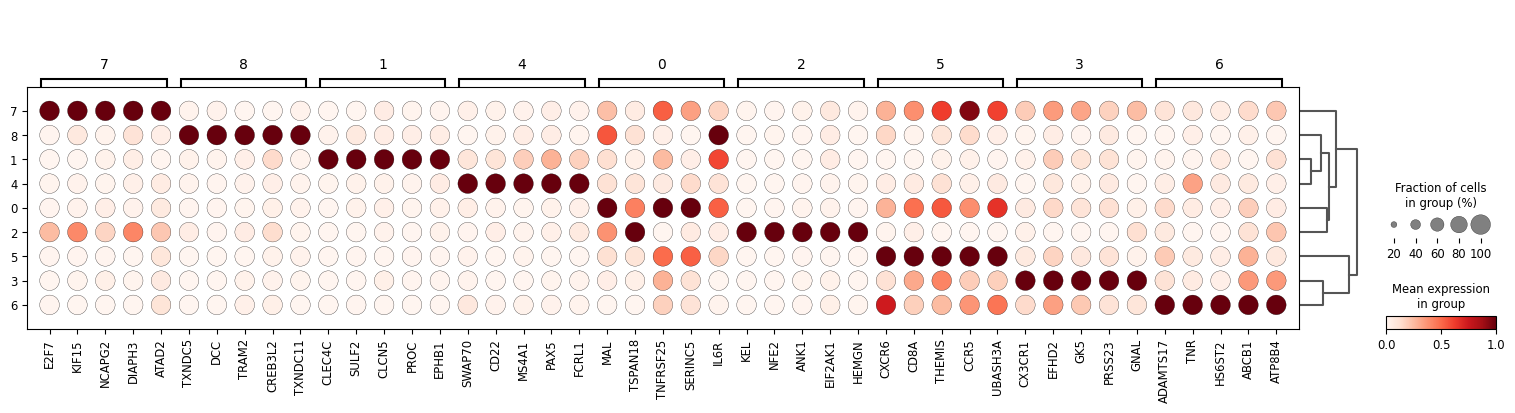

Counter({'5': 30225, '0': 19372, '3': 11867, '6': 2886, '4': 2614, '8': 1118, '7': 631, '2': 239, '1': 176})
CPU times: user 2min 14s, sys: 56min 5s, total: 58min 19s
Wall time: 1min 22s


['leiden0.25',
 AnnData object with n_obs × n_vars = 69128 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'total_UMI', 'log10_UMI', 'endo_score', 'cm_score', 'fib_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'l

In [7]:
%%time
leiden_key = "leiden0.25"
funcs.specify_leiden_subclustering(adata=adata, leiden=leiden_key)

In [8]:
adata.obs['age_disease'] = adata.obs['age_status'].astype(str) + ":" + adata.obs['disease'].astype(str)

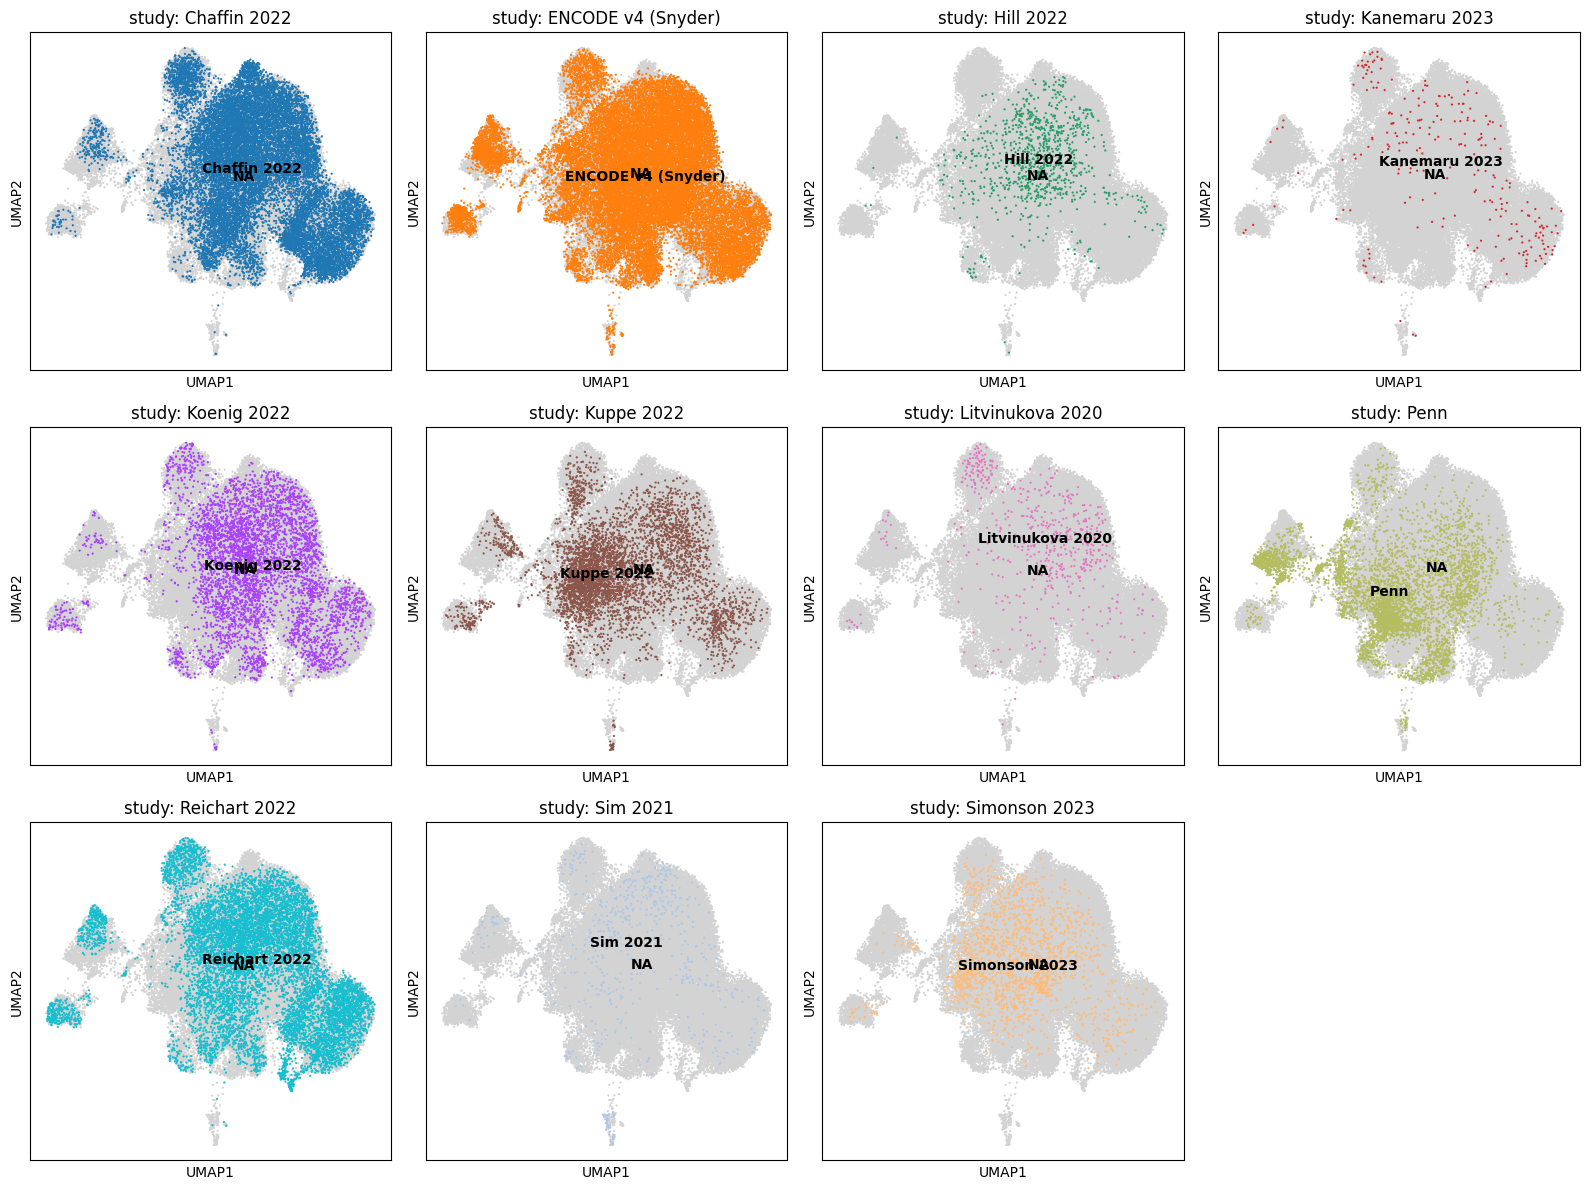

In [9]:
funcs.plot_umap_by_cluster(adata, metadata_key = "study")

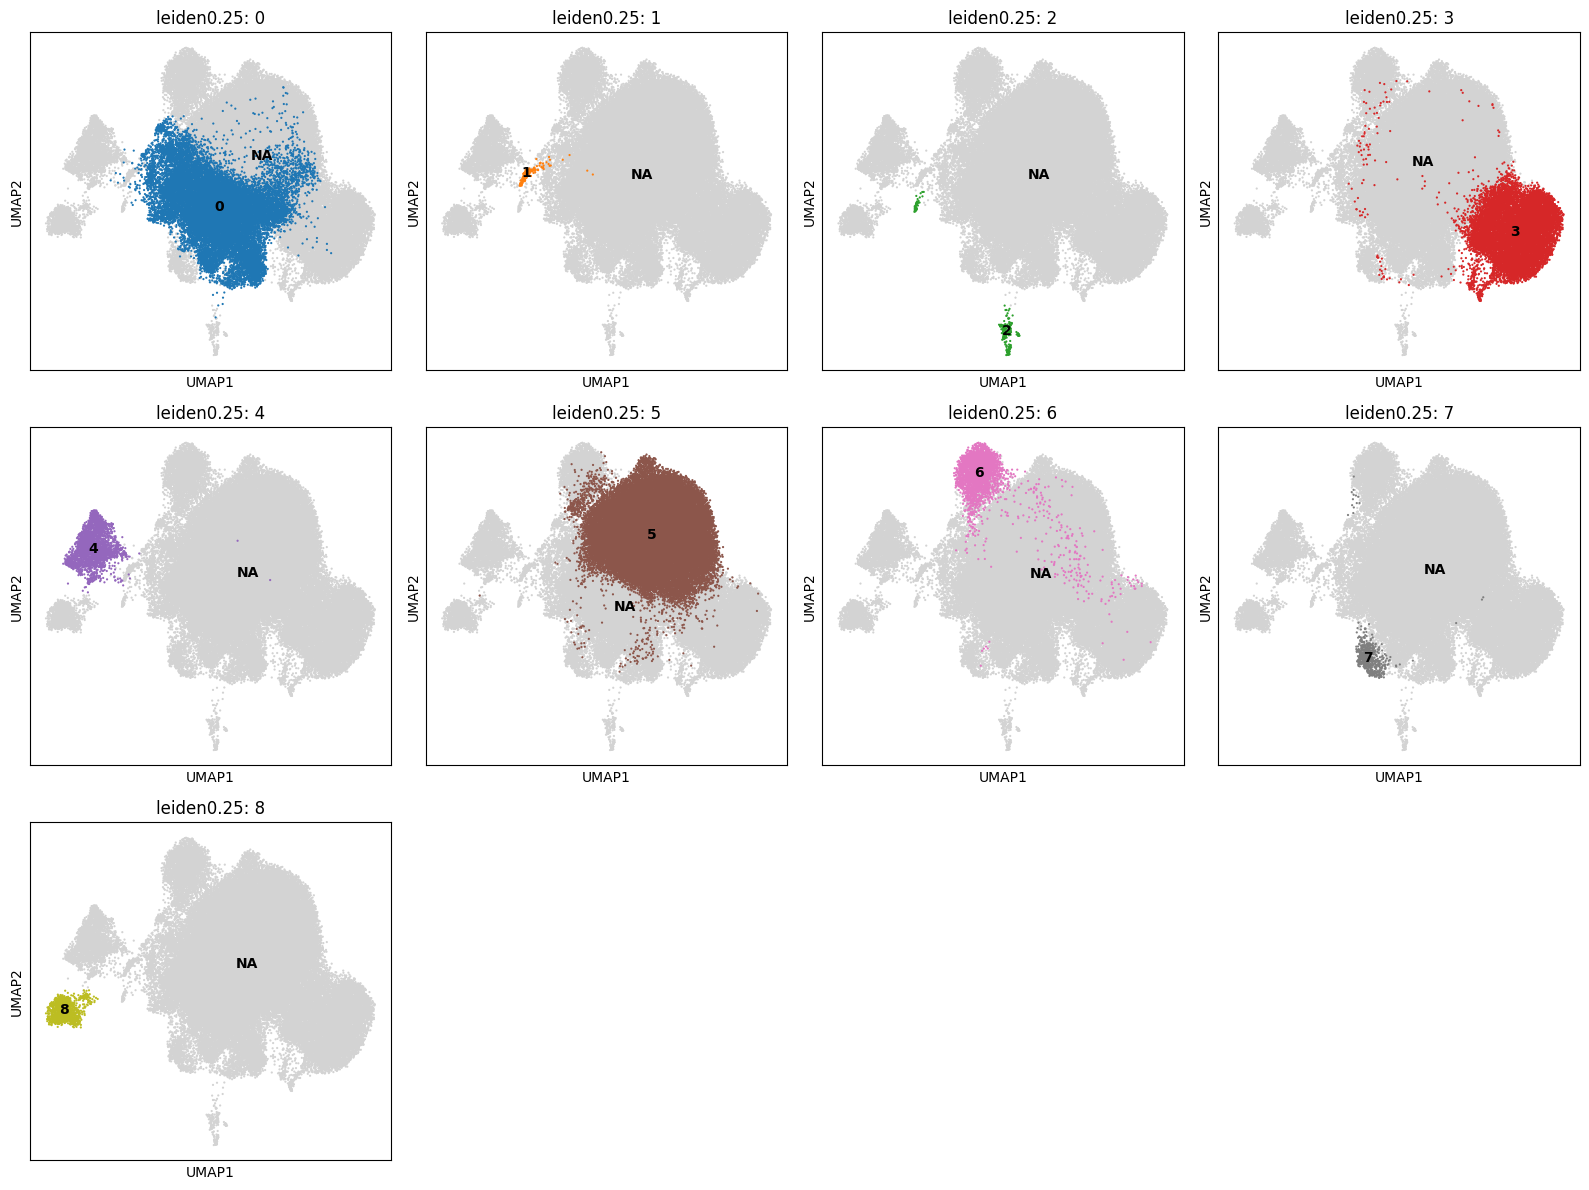

In [10]:
funcs.plot_umap_by_cluster(adata, metadata_key = leiden_key)

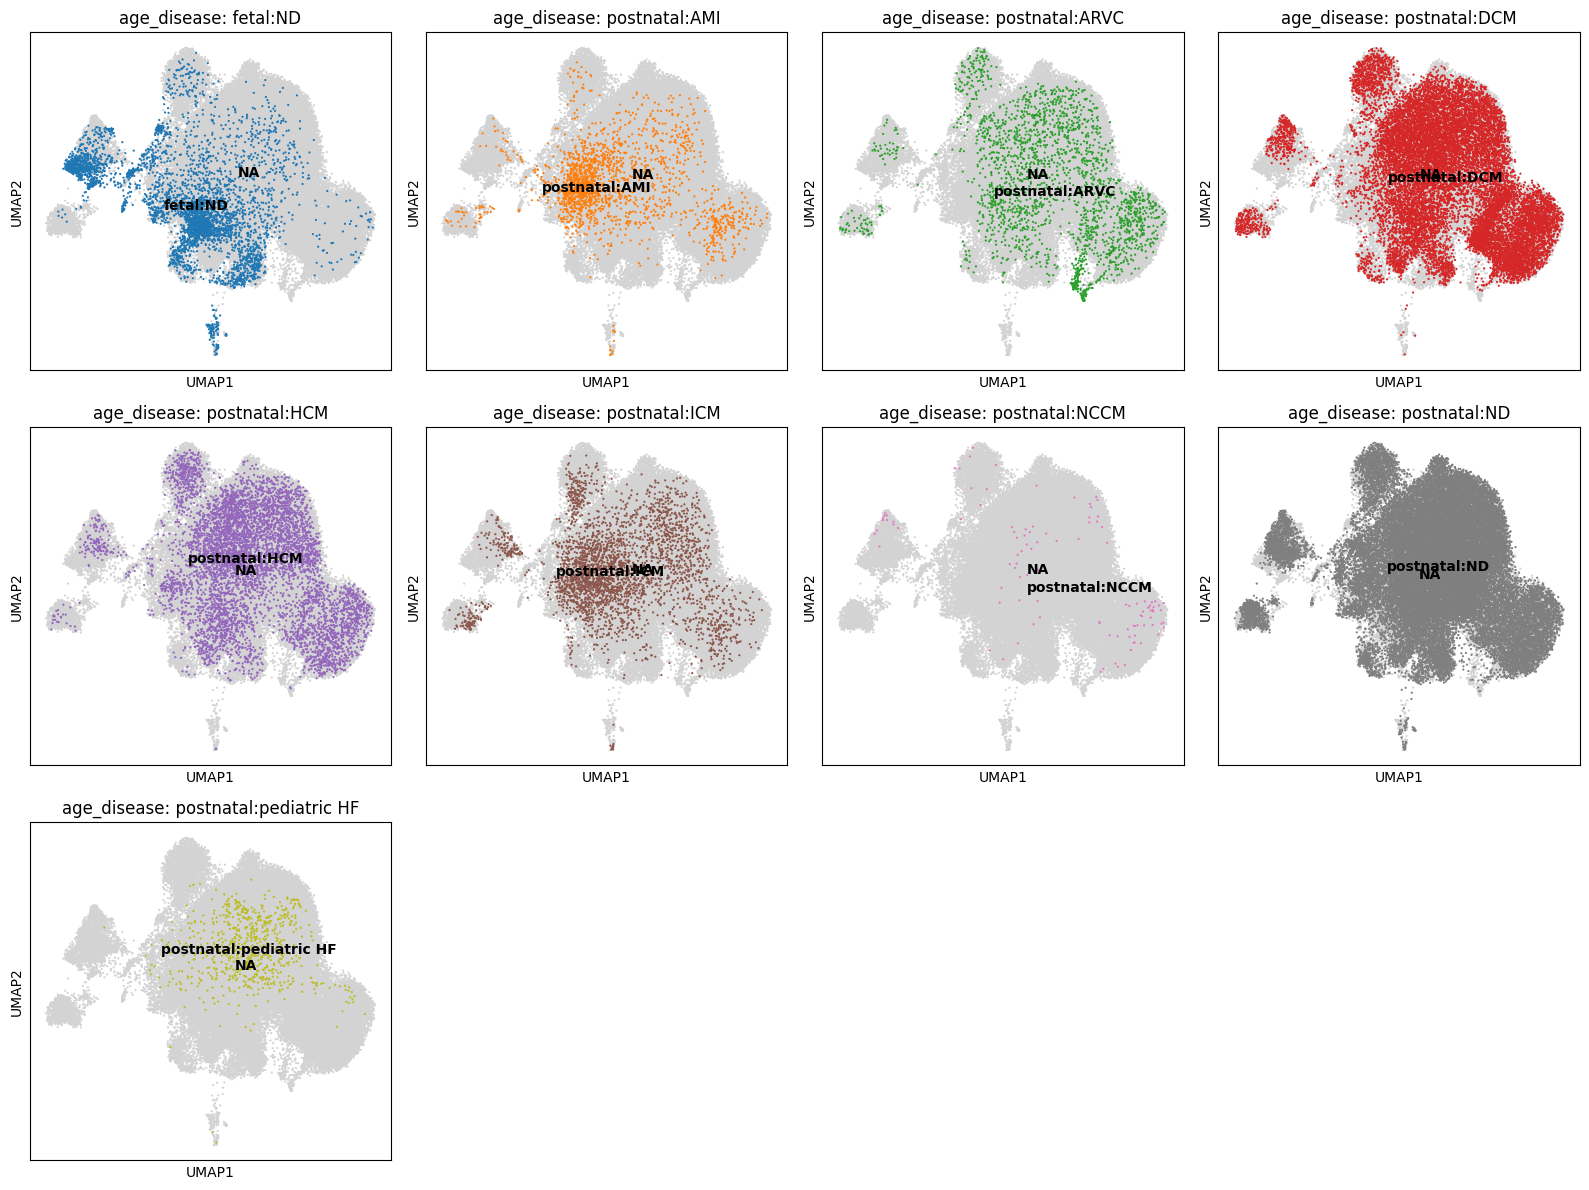

In [11]:
funcs.plot_umap_by_cluster(adata, metadata_key = "age_disease")

### Examine enrichment along metadata categories

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


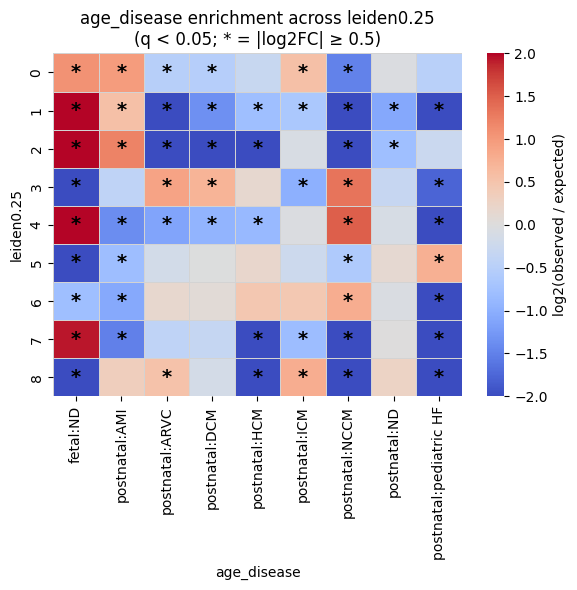

In [12]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=adata.obs,
    cluster_label=leiden_key,
    study_col="age_disease",
    min_cells=50, figsize_tuple = (6,6)
)

### Marker gene / ORA analysis

In [13]:
#sc.get.rank_genes_groups_df(adata, group="0").head(50)['names']

In [14]:
#funcs.plot_all_cluster_enrichment(
#     adata, cluster_key=leiden_key, 
#     gene_sets=["MSigDB_Hallmark_2020"], outdir=None,top_n=100)

### Subcluster annotation

- Cluster 0: CD4+ naive T-cells : TCF7/CD4/CD28/CD5/CCR7
- Cluster 1: Plasmacytoid Dendritic cells: CLEC4C/IRF8/TCF4
- Cluster 2: Likely erythroid precursors: GATA1/KLF1/ANK1
- Cluster 3: Circulating NK cells: CX3CR1/PRF1/GNLY/FCGR3A
- Cluster 4: B cells: MS4A1/CD79A/CD22
- Cluster 5: Cytotoxic T-cells: CD8A/CD3E/GZMK
- Cluster 6: Tissue-resident NK cells: NCR1/KLRC1/KLRC2/ITGAE
- Cluster 7: Cycling cells: E2F7/EZH2/AURKB
- Cluster 8: Plasma B cells: SDC1/XBP1/MZB1

In [15]:
adata.obs['subcluster'] = adata.obs[leiden_key].map(
    {"0": "T_helper",
     "1": "pDC",
     "2": "Erythroid",
     "3": "NK_1",
     "4": "B",
     "5": "T_cytotoxic",
     "6": "NK_2",
     "7": "Cycling",
     "8": "B_plasma"
    }
)

#### remove the Erythroid cells

In [16]:
filt_adata = adata[adata.obs.subcluster != "Erythroid"].copy()

In [47]:
subcluster_order = ["B", "B_plasma", "Cycling", "pDC",
                     "NK_1", "NK_2", "T_cytotoxic", "T_helper"]

filt_adata.obs['subcluster'] = pd.Categorical(
    filt_adata.obs['subcluster'], categories=subcluster_order, ordered=True
)

subcluster_colors = {
    "T_helper": "blue",     
    "pDC": "gray",    
    "NK_1": "magenta",          
    "NK_2": "purple",          
    "B": "cyan",              
    "B_plasma": "lightblue",      
    "T_cytotoxic": "red",
    "Cycling": "yellow"
}

# apply colors to scanpy
filt_adata.uns['subcluster_colors'] = [
    subcluster_colors[sc] for sc in filt_adata.obs['subcluster'].cat.categories
]

### Produce plots

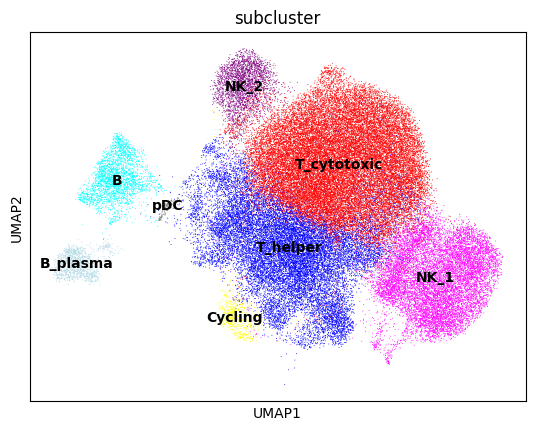

In [48]:
with plt.rc_context(): 
    sc.pl.umap(filt_adata, color = ['subcluster'], legend_loc = "on data", palette = subcluster_colors, show=False)
    plt.savefig(plots_dir + cell_type + "_subclustered.pdf", bbox_inches="tight")

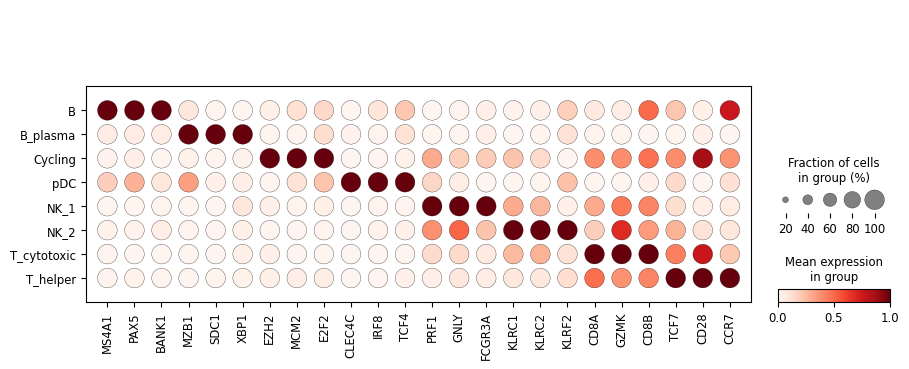

In [49]:
with plt.rc_context(): 
    sc.pl.dotplot(filt_adata, var_names = ["MS4A1", "PAX5", "BANK1",
                                      "MZB1", "SDC1", "XBP1",
                                     "EZH2", "MCM2", "E2F2", 
                                      "CLEC4C","IRF8", "TCF4",
                                     "PRF1", "GNLY", "FCGR3A",
                                     "KLRC1", "KLRC2", "KLRF2",
                                     "CD8A", "GZMK", "CD8B",
                                    "TCF7", "CD28", "CCR7"], groupby = "subcluster",standard_scale='var', show=False)
    plt.savefig(plots_dir + cell_type + "_subclustered_dotplot.pdf", bbox_inches="tight")

### Show the enrichments by subcluster

In [50]:
adata_metadata = filt_adata.obs

disease_filtered_metadata = adata_metadata[~adata_metadata['age_disease'].isin(["postnatal:ARVC", "postnatal:NCCM"])].copy()
for col in disease_filtered_metadata.select_dtypes('category').columns:
    disease_filtered_metadata[col] = disease_filtered_metadata[col].cat.remove_unused_categories()
    
ND_adata_metadata = adata_metadata[adata_metadata['disease_binary'] == "N"].copy()

In [52]:
#disease_filtered_metadata.subcluster

In [55]:
#subcluster_order = sorted(disease_filtered_metadata["subcluster"].astype(str).unique())
subcluster_order = ['B', 'B_plasma', 'Cycling', 'pDC', 'NK_1', 'NK_2', 'T_cytotoxic', 'T_helper']

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


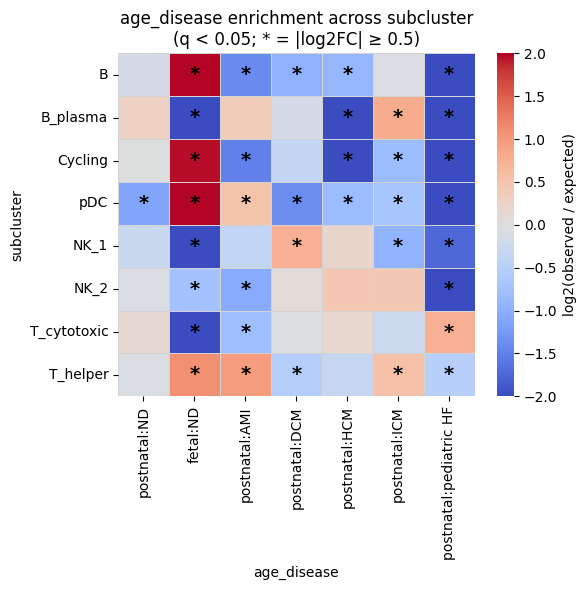

In [56]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=disease_filtered_metadata,
    cluster_label="subcluster",
    subcluster_order = subcluster_order,
    study_col="age_disease",
    metadata_order = ['postnatal:ND', 'fetal:ND', 'postnatal:AMI', 'postnatal:DCM', 
                      'postnatal:HCM', 'postnatal:ICM', 'postnatal:pediatric HF'],
    min_cells=50, figsize_tuple = (6,6)
)

plot.savefig(plots_dir + cell_type + "_subcluster_age_disease.pdf")

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


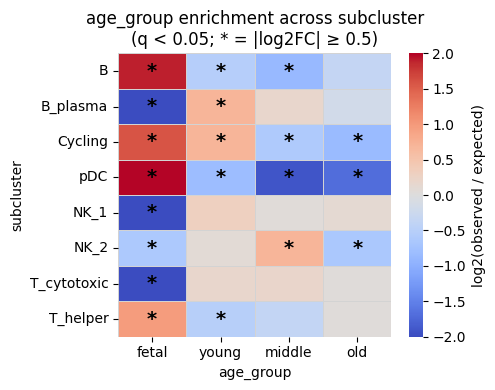

In [57]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=ND_adata_metadata,
    cluster_label="subcluster",
     subcluster_order = subcluster_order,
    metadata_order = ["fetal", "young", "middle", "old"],
    study_col="age_group",
    min_cells=50, figsize_tuple = (5,4)
)

plot.savefig(plots_dir + cell_type + "_subcluster_aging.pdf")

In [58]:
subcluster_stats = (
    filt_adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()

print(subcluster_stats)

    subcluster  count  proportion
0  T_cytotoxic  30225    0.438749
1     T_helper  19372    0.281206
2         NK_1  11867    0.172263
3         NK_2   2886    0.041893
4            B   2614    0.037945
5     B_plasma   1118    0.016229
6      Cycling    631    0.009160
7          pDC    176    0.002555


### Save metadata

In [59]:
filt_adata.obs.to_csv(post_subclustering_dir + cell_type + "_annotation.csv")